# Hacker News'te Başarılı İçeriğin Anatomisi

Bu projede Hacker News gönderilerinin başarısını etkileyen faktörler incelenmektedir.

Amaç:

Bir gönderinin viral olup olmayacağını tahmin etmek.

Kullanılan Teknolojiler:

- DuckDB SQL
- Python
- Pandas
- plotly.express
- Scikit-Learn

Kullanılan Modeller:

- Gaussian Naive Bayes
- K-Nearest Neighbors (KNN)

## 1. Kütüphanelerin Yüklenmesi

Bu bölümde veri analizi, görselleştirme ve makine öğrenmesi için gerekli kütüphaneler yüklenmektedir.

In [13]:
import duckdb
import pandas as pd
import numpy as np

import plotly.express as px

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## 2. Veri Setinin Yüklenmesi

Bu bölümde Hacker News veri seti içerisinden yalnızca story tipindeki kayıtlar çekilmektedir.

In [14]:
query = """
SELECT
    title,
    score,
    descendants,
    time,
    url
FROM 's3://bauntek-bootcamp-shared/hackernews.parquet'
WHERE type = 'story'
  AND title IS NOT NULL
"""

df = duckdb.sql(query).df()

print("Veri Boyutu:", df.shape)

df.head()

Veri Boyutu: (147137, 5)


,title,score,descendants,time,url
0,What Arc should learn from Ruby,33,10,2008-10-26 05:07:59,http://antoniocangiano.com/2008/10/26/what-arc...
1,How to make your own spectrometer from a CD an...,1,0,2008-10-26 05:17:05,http://www.cs.cmu.edu/~zhuxj/astro/html/spectr...
2,Free Samples : Free Stuff : Freebies,1,-1,2008-10-26 05:21:03,http://www.freestufffriend.com
3,Great Source for Astrology,1,-1,2008-10-26 05:30:21,http://www.astrology-signs.org/
4,Shuttleworth - GNOME usability hackfest,18,4,2008-10-26 05:42:22,http://www.markshuttleworth.com/archives/223


## 3. Veri Kalitesinin İncelenmesi

Makine öğrenmesi modeline geçmeden önce veri setinin genel yapısı ve eksik değerleri incelenmektedir.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147137 entries, 0 to 147136
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   title        147137 non-null  object        
 1   score        147137 non-null  int32         
 2   descendants  147137 non-null  int32         
 3   time         147137 non-null  datetime64[us]
 4   url          137164 non-null  object        
dtypes: datetime64[us](1), int32(2), object(2)
memory usage: 4.5+ MB


In [16]:
df.isnull().sum()

title             0
score             0
descendants       0
time              0
url            9973
dtype: int64

In [17]:
df.describe()

,score,descendants,time
count,147137.000000,147137.000000,147137
mean,10.078478,4.634395,2013-06-09 07:43:23.964822
min,0.000000,-1.000000,2006-10-09 18:21:51
25%,1.000000,0.000000,2008-12-07 05:18:18
50%,2.000000,0.000000,2014-04-07 17:49:13
75%,4.000000,1.000000,2017-07-13 14:41:03
max,1990.000000,1590.000000,2020-01-09 18:06:29
std,43.036079,24.037511,NaN


## 4. Score Dağılımının İncelenmesi

Bu bölümde gönderi puanlarının dağılımı incelenerek viral içerik tanımı için uygun eşik belirlenmektedir.

In [18]:
df["score"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    147137.000000
mean         10.078478
std          43.036079
min           0.000000
25%           1.000000
50%           2.000000
75%           4.000000
90%          13.000000
95%          39.000000
99%         180.000000
max        1990.000000
Name: score, dtype: float64

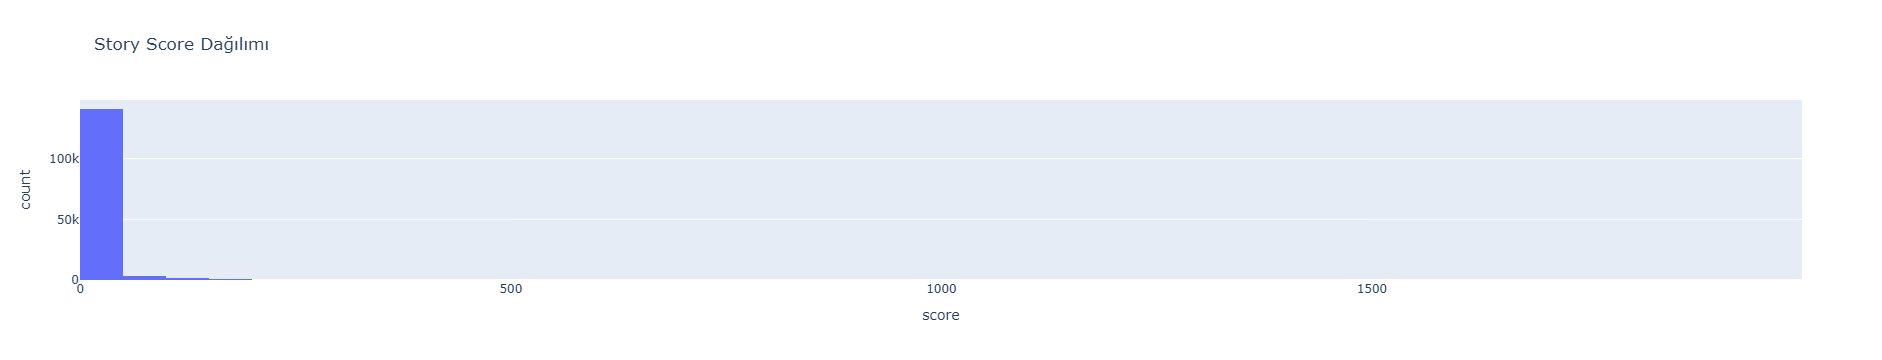

In [19]:
fig = px.histogram(
    df,
    x="score",
    nbins=50,
    title="Story Score Dağılımı"
)

fig.show()

In [20]:
df["score"].describe(
    percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]
)

count    147137.000000
mean         10.078478
std          43.036079
min           0.000000
25%           1.000000
50%           2.000000
75%           4.000000
90%          13.000000
95%          39.000000
99%         180.000000
max        1990.000000
Name: score, dtype: float64

## 5. Feature Engineering

Makine öğrenmesi modelinde kullanılacak yeni özellikler oluşturulmaktadır.

Oluşturulan özellikler:

- Başlık uzunluğu
- Paylaşım saati
- Ask HN gönderisi mi?
- Show HN gönderisi mi?
- URL içeriyor mu?
- Viral mi?

In [21]:
df["title_length"] = df["title"].str.len()

df["hour"] = pd.to_datetime(df["time"]).dt.hour

df["is_ask_hn"] = (
    df["title"]
    .str.startswith("Ask HN", na=False)
    .astype(int)
)

df["is_show_hn"] = (
    df["title"]
    .str.startswith("Show HN", na=False)
    .astype(int)
)

df["has_url"] = df["url"].notna().astype(int)

df["viral"] = (df["score"] >= 50).astype(int)

df.head()

,title,score,descendants,time,url,title_length,hour,is_ask_hn,is_show_hn,has_url,viral
0,What Arc should learn from Ruby,33,10,2008-10-26 05:07:59,http://antoniocangiano.com/2008/10/26/what-arc...,31,5,0,0,1,0
1,How to make your own spectrometer from a CD an...,1,0,2008-10-26 05:17:05,http://www.cs.cmu.edu/~zhuxj/astro/html/spectr...,60,5,0,0,1,0
2,Free Samples : Free Stuff : Freebies,1,-1,2008-10-26 05:21:03,http://www.freestufffriend.com,36,5,0,0,1,0
3,Great Source for Astrology,1,-1,2008-10-26 05:30:21,http://www.astrology-signs.org/,26,5,0,0,1,0
4,Shuttleworth - GNOME usability hackfest,18,4,2008-10-26 05:42:22,http://www.markshuttleworth.com/archives/223,40,5,0,0,1,0


In [22]:
df[
    [
        "title",
        "title_length",
        "hour",
        "is_ask_hn",
        "is_show_hn",
        "has_url",
        "viral"
    ]
].head()

,title,title_length,hour,is_ask_hn,is_show_hn,has_url,viral
0,What Arc should learn from Ruby,31,5,0,0,1,0
1,How to make your own spectrometer from a CD an...,60,5,0,0,1,0
2,Free Samples : Free Stuff : Freebies,36,5,0,0,1,0
3,Great Source for Astrology,26,5,0,0,1,0
4,Shuttleworth - GNOME usability hackfest,40,5,0,0,1,0


In [23]:
df["viral"].value_counts()

viral
0    140926
1      6211
Name: count, dtype: int64

## 6. Oluşturulan Özelliklerin Analizi

In [27]:
title_analysis = (
    df.groupby("title_length")
      .agg(
          ort_puan=("score", "mean"),
          adet=("score", "count")
      )
      .reset_index()
)

title_analysis = title_analysis[
    title_analysis["adet"] >= 20
]
title_analysis.head()

,title_length,ort_puan,adet
1,2,2.238095,42
2,3,10.235294,68
3,4,4.435897,156
4,5,3.157143,140
5,6,8.380435,184


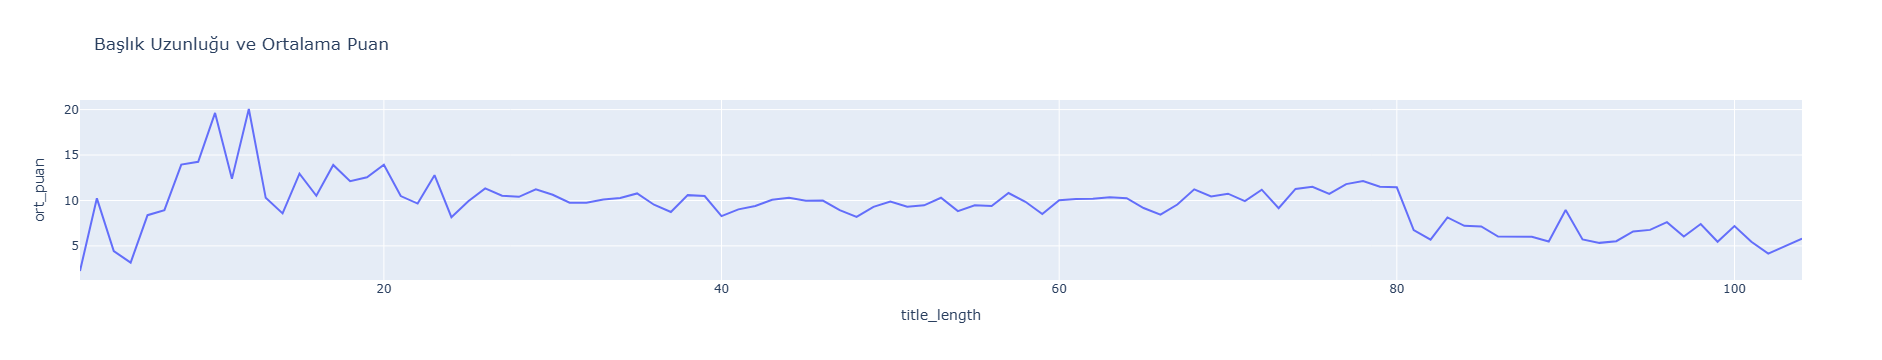

In [26]:
fig = px.line(
    title_analysis,
    x="title_length",
    y="ort_puan",
    title="Başlık Uzunluğu ve Ortalama Puan"
)

fig.show()

In [28]:
df["title_group"] = pd.cut(
    df["title_length"],
    bins=[0, 20, 40, 60, 80, 200],
    labels=["0-20", "21-40", "41-60", "61-80", "80+"]
)

In [30]:
title_group_analysis = (
    df.groupby("title_group")
      .agg(
          ort_puan=("score", "mean"),
          ort_viral=("viral", "mean"),
          adet=("score", "count")
      )
      .reset_index()
)

title_group_analysis

/tmp/ipykernel_2078/2093806002.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("title_group")


,title_group,ort_puan,ort_viral,adet
0,0-20,12.468726,0.050332,10232
1,21-40,10.113454,0.042967,45710
2,41-60,9.542972,0.040360,54955
3,61-80,10.486418,0.044179,33500
4,80+,6.321898,0.012409,2740


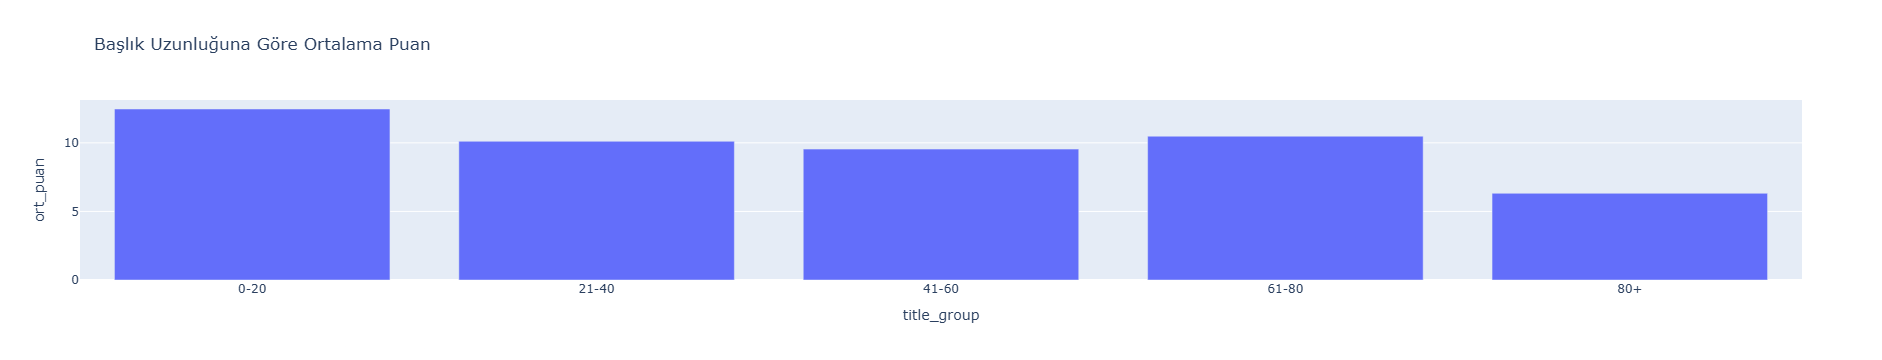

In [31]:
fig = px.bar(
    title_group_analysis,
    x="title_group",
    y="ort_puan",
    title="Başlık Uzunluğuna Göre Ortalama Puan"
)

fig.show()

## 7. Paylaşım Saati Analizi

Bu bölümde gönderinin paylaşım saatinin aldığı puan üzerindeki etkisi incelenmektedir.

In [32]:
hour_analysis = (
    df.groupby("hour")
      .agg(
          ort_puan=("score", "mean"),
          ort_viral=("viral", "mean"),
          adet=("score", "count")
      )
      .reset_index()
)

hour_analysis

,hour,ort_puan,ort_viral,adet
0,0,9.615067,0.041109,5084
1,1,10.251000,0.042114,4749
2,2,10.368397,0.041853,4468
3,3,8.164427,0.034844,4391
4,4,8.996081,0.035758,4083
5,5,7.846262,0.035496,4254
6,6,8.600535,0.032992,4486
7,7,8.848829,0.035008,4399
8,8,8.070790,0.033906,4365
9,9,8.771149,0.037622,4492


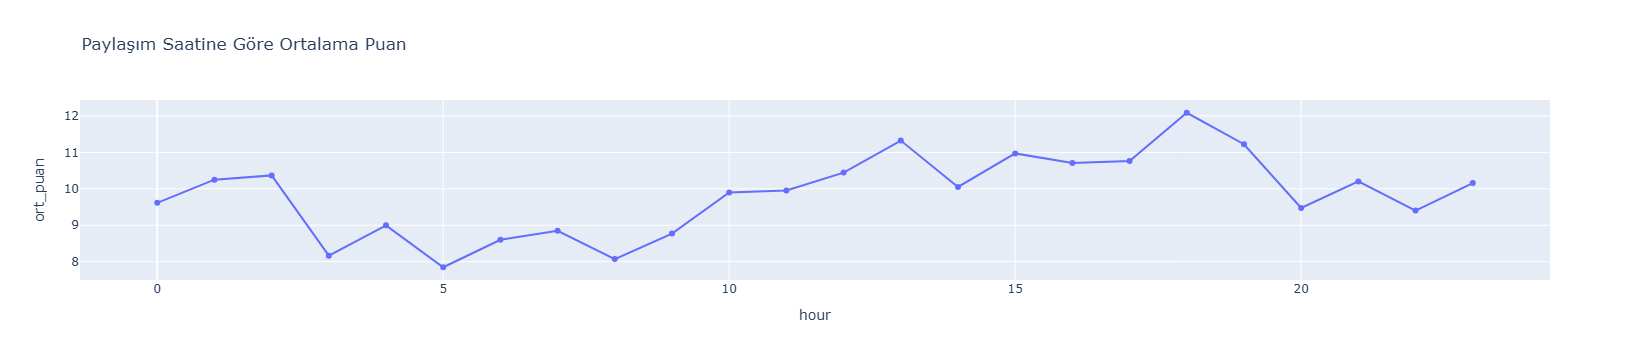

In [33]:
fig = px.line(
    hour_analysis,
    x="hour",
    y="ort_puan",
    markers=True,
    title="Paylaşım Saatine Göre Ortalama Puan"
)

fig.show()

## 8. Gönderi Türü Analizi

Ask HN ve Show HN gönderilerinin performansı incelenmektedir.

In [34]:
def classify_post(title):
    
    if title.startswith("Ask HN"):
        return "Ask HN"
    
    elif title.startswith("Show HN"):
        return "Show HN"
    
    else:
        return "Normal Story"

df["post_type"] = df["title"].apply(classify_post)

df["post_type"].value_counts()

post_type
Normal Story    140279
Ask HN            4142
Show HN           2716
Name: count, dtype: int64

In [35]:
post_type_analysis = (
    df.groupby("post_type")
      .agg(
          ort_puan=("score", "mean"),
          ort_yorum=("descendants", "mean"),
          adet=("score", "count")
      )
      .reset_index()
)

post_type_analysis

,post_type,ort_puan,ort_yorum,adet
0,Ask HN,11.946886,11.389184,4142
1,Normal Story,9.916680,4.410211,140279
2,Show HN,15.585788,5.912003,2716


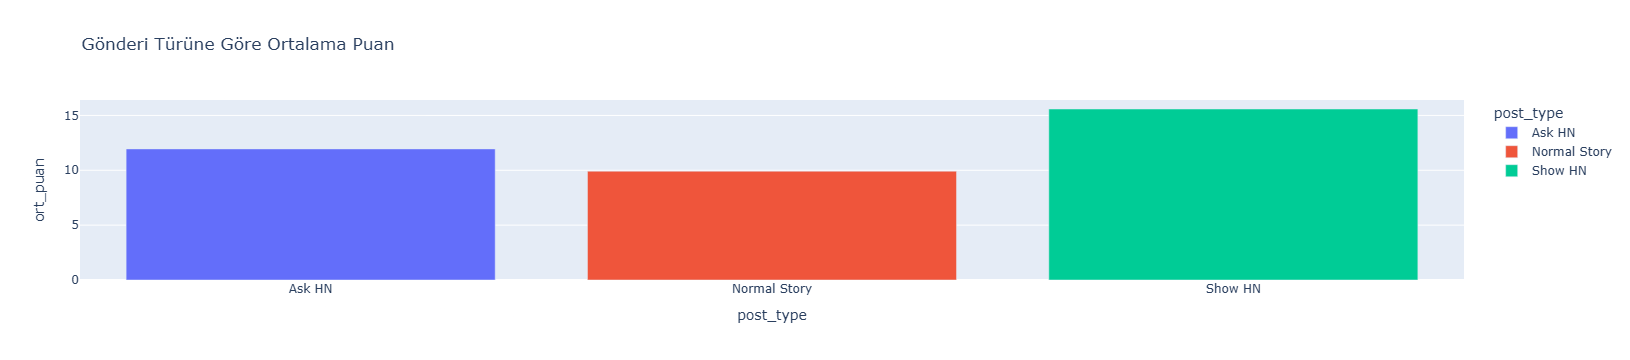

In [36]:
fig = px.bar(
    post_type_analysis,
    x="post_type",
    y="ort_puan",
    color="post_type",
    title="Gönderi Türüne Göre Ortalama Puan"
)

fig.show()

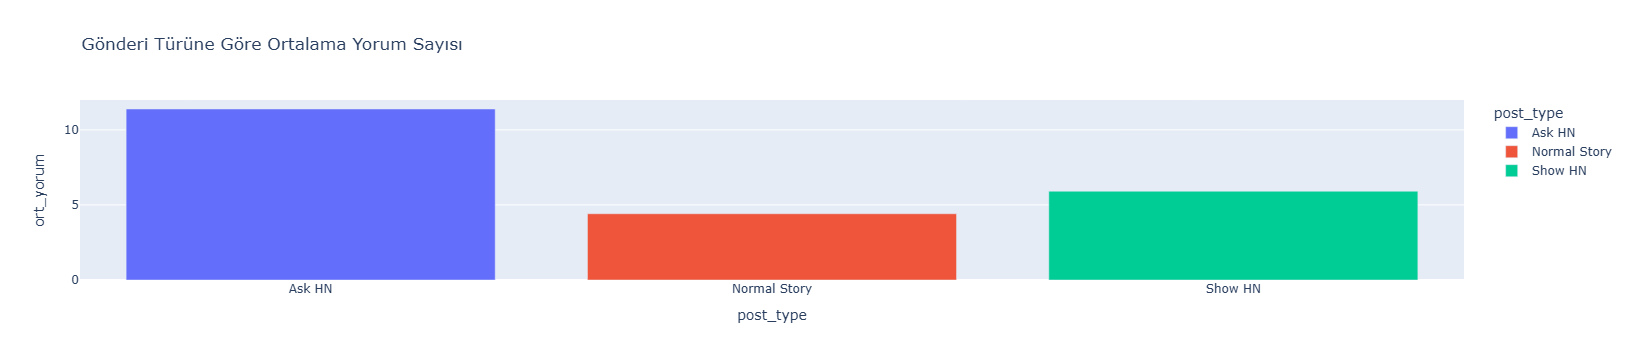

In [38]:
fig = px.bar(
    post_type_analysis,
    x="post_type",
    y="ort_yorum",
    color="post_type",
    title="Gönderi Türüne Göre Ortalama Yorum Sayısı"
)

fig.show()

## 9. Makine Öğrenmesi İçin Veri Hazırlama

Bu bölümde oluşturulan özellikler kullanılarak modelleme için veri seti hazırlanmıştır.

In [39]:
features = [
    "title_length",
    "hour",
    "is_ask_hn",
    "is_show_hn",
    "has_url"
]

X = df[features]

y = df["viral"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (147137, 5)
y Shape: (147137,)


In [40]:
X.head()

,title_length,hour,is_ask_hn,is_show_hn,has_url
0,31,5,0,0,1
1,60,5,0,0,1
2,36,5,0,0,1
3,26,5,0,0,1
4,40,5,0,0,1


## 10. Eğitim ve Test Verilerinin Oluşturulması

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (117709, 5)
Test : (29428, 5)


## 11. Gaussian Naive Bayes Modeli

In [42]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [43]:
print("Accuracy:")
print(accuracy_score(y_test, nb_pred))

Accuracy:
0.9414843006660324


In [44]:
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     28186
           1       0.09      0.04      0.05      1242

    accuracy                           0.94     29428
   macro avg       0.52      0.51      0.51     29428
weighted avg       0.92      0.94      0.93     29428



In [45]:
cm = confusion_matrix(y_test, nb_pred)

print(cm)

[[27656   530]
 [ 1192    50]]


## 12. K-Nearest Neighbors (KNN) Modeli

Bu bölümde KNN algoritması kullanılarak viral gönderi tahmini yapılmıştır.

In [55]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

In [56]:
print("Accuracy:")
print(accuracy_score(y_test, knn_pred))

Accuracy:
0.9574894658148702


In [57]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     28186
           1       0.00      0.00      0.00      1242

    accuracy                           0.96     29428
   macro avg       0.48      0.50      0.49     29428
weighted avg       0.92      0.96      0.94     29428



In [58]:
cm_knn = confusion_matrix(y_test, knn_pred)

print(cm_knn)

[[28177     9]
 [ 1242     0]]


In [59]:
results = pd.DataFrame({
    "Model": ["GaussianNB", "KNN"],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, knn_pred)
    ]
})

results

,Model,Accuracy
0,GaussianNB,0.941484
1,KNN,0.957489


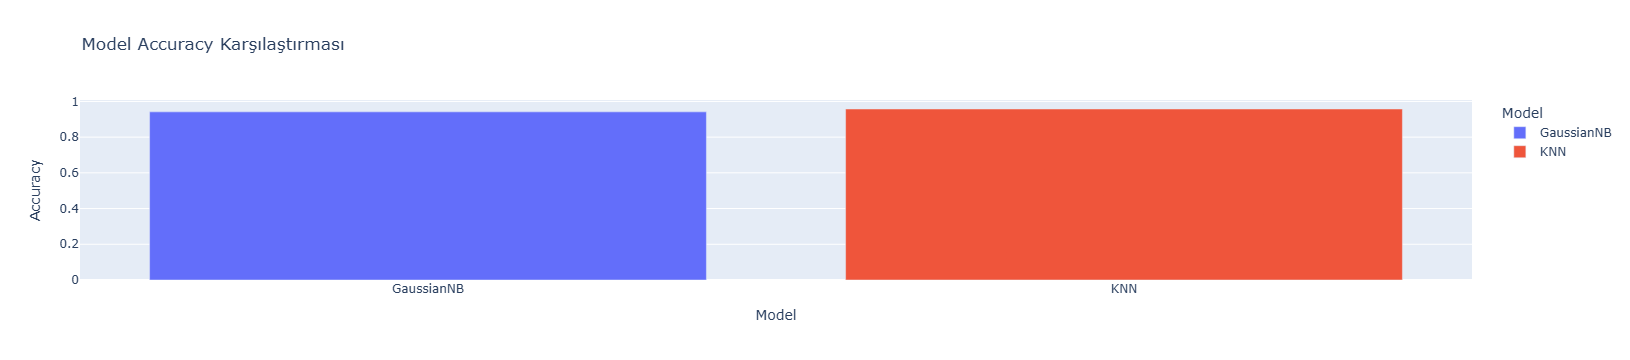

In [51]:
fig = px.bar(
    results,
    x="Model",
    y="Accuracy",
    color="Model",
    title="Model Accuracy Karşılaştırması"
)

fig.show()

# 14. Sonuç

Bu çalışmada Hacker News gönderilerinin viral olup olmayacağını tahmin etmek amacıyla Gaussian Naive Bayes ve KNN algoritmaları uygulanmıştır.

Veri analizi sonucunda başlık uzunluğu, paylaşım saati ve gönderi türünün gönderi başarısını etkileyebildiği gözlemlenmiştir.

Model sonuçlarında KNN algoritması daha yüksek Accuracy değeri elde etmiş olsa da viral gönderileri tespit etmekte başarısız olmuştur. Gaussian Naive Bayes modeli ise az da olsa viral gönderileri yakalayabilmiştir.

Bu sonuçlar, dengesiz veri setlerinde Accuracy metriğinin tek başına yeterli olmadığını ve Recall ile F1 Score gibi metriklerin de değerlendirilmesi gerektiğini göstermektedir.